<a href="https://colab.research.google.com/github/febinemmanuel/CNN_Car-classification/blob/main/Model/Car_Classification_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing Libraries

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import numpy as np
import cv2
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout,BatchNormalization
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.utils import to_categorical
from PIL import Image
from keras.regularizers import l2

# Reading Dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
directory = "/content/drive/MyDrive/AI ML/IRP/datasets/dataset/DATA"
categories = ['Golf','bmw serie 1','chevrolet spark','chevroulet aveo','clio','duster','hyundai i10','hyundai tucson','logan','megane','mercedes class a','nemo citroen','octavia','picanto','polo','sandero','seat ibiza','symbol','toyota corolla','volkswagen tiguan']

# EDA

In [4]:
img_size = 64
data = []
labels = []

# Iterate over each category
for category in categories:
    category_dir = os.path.join(directory, category)

    # Iterate over each file in the category directory
    for filename in os.listdir(category_dir):
        # Check if the file is an image (you might want to add more sophisticated checks)
        if filename.endswith(".jpg") or filename.endswith(".png"):
            # Load image with error handling
            try:
                image_path = os.path.join(category_dir, filename)
                image = Image.open(image_path)

                # Resize image and convert to grayscale
                image = image.resize((img_size, img_size)).convert('L')

                # Convert image to numpy array
                image_array = np.array(image)

                # Append the image array to the data list
                data.append(image_array)

                # Append the label corresponding to the category
                labels.append(categories.index(category))  # Use index as label (assuming categories are ordered)
            except Exception as e:
                print(f"Error loading image {filename}: {e}")

# Convert data and labels to numpy arrays
data = np.array(data)
labels = np.array(labels)

# Reshape data to have a single channel for grayscale images (if needed)
data = data.reshape(-1, img_size, img_size, 1)

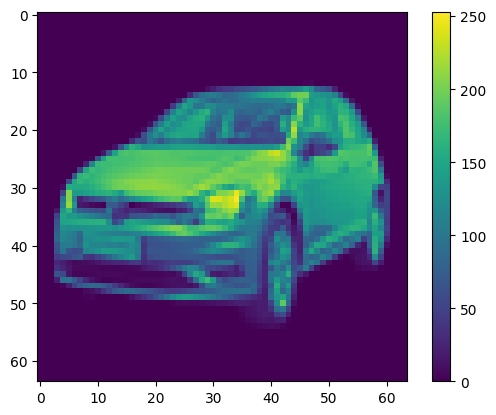

In [6]:
plt.figure()
plt.imshow(data[0])
plt.colorbar()
plt.grid(False)
plt.show()

In [7]:
data = np.array(data)
labels = np.array(labels)

In [8]:
print(data[0])


[[[0]
  [0]
  [0]
  ...
  [0]
  [0]
  [0]]

 [[0]
  [0]
  [0]
  ...
  [0]
  [0]
  [0]]

 [[0]
  [0]
  [0]
  ...
  [0]
  [0]
  [0]]

 ...

 [[0]
  [0]
  [0]
  ...
  [0]
  [0]
  [0]]

 [[0]
  [0]
  [0]
  ...
  [0]
  [0]
  [0]]

 [[0]
  [0]
  [0]
  ...
  [0]
  [0]
  [0]]]


# Preprocessing

In [9]:
data = data.astype('float32') / 255.0


In [5]:
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)


In [9]:
print(y_train)


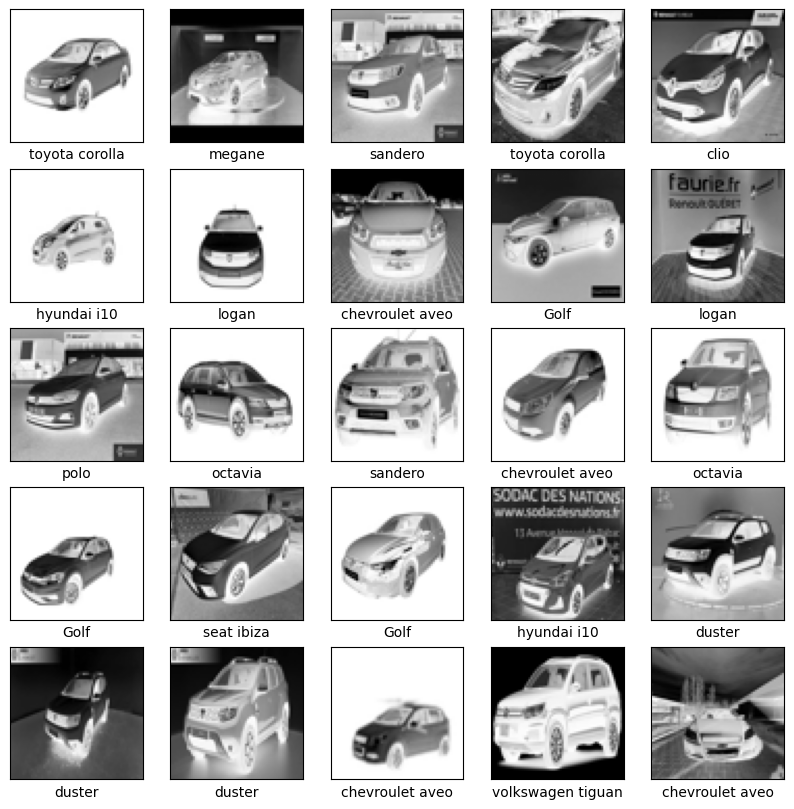

In [10]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap=plt.cm.binary)
    plt.xlabel(categories[y_train[i]])
plt.show()

##Model building

In [11]:
# Define the model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(len(categories), activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 685,204 (2.61 MB)

 Trainable params: 685,204 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Fit the model
history = model.fit(X_train, y_train, epochs=500, batch_size=32, validation_split=0.2)

Epoch 1/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 14s 128ms/step - accuracy: 0.0812 - loss: 6.5403 - val_accuracy: 0.1255 - val_loss: 2.8332
Epoch 2/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.1797 - loss: 2.7226 - val_accuracy: 0.2452 - val_loss: 2.5989
Epoch 3/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3193 - loss: 2.3044 - val_accuracy: 0.2568 - val_loss: 2.4104
Epoch 4/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5019 - loss: 1.7108 - val_accuracy: 0.3571 - val_loss: 2.1591
Epoch 5/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6705 - loss: 1.1066 - val_accuracy: 0.4305 - val_loss: 2.0223
Epoch 6/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8353 - loss: 0.5669 - val_accuracy: 0.4749 - val_loss: 2.0826
Epoch 7/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9150 - loss: 0.2868 - val_accuracy: 0.5405 - val_loss: 2.2179
Epoch 8/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9715 - loss: 0.1165 - val_accuracy: 0.5811 

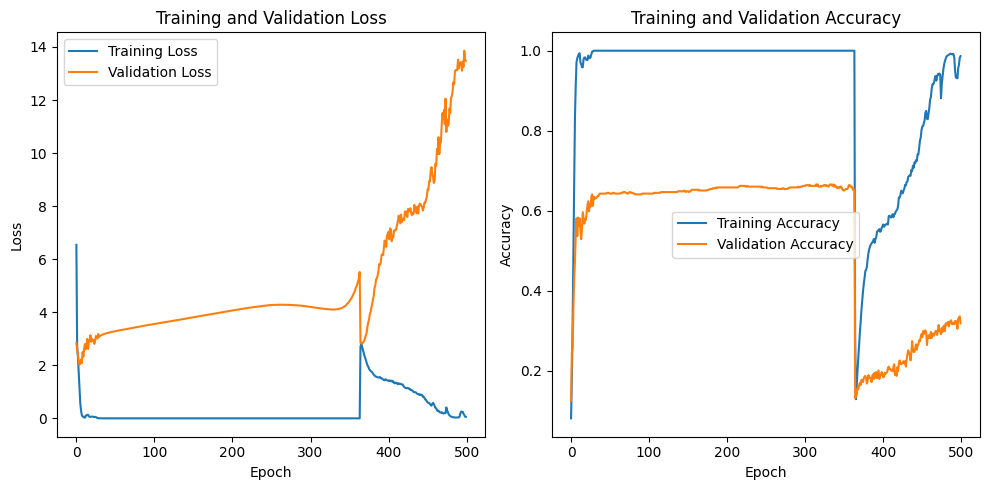

In [15]:
# Get training and validation loss
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Get training and validation accuracy
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [16]:
# Define the model with drop out
model2 = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 1)),
    MaxPooling2D((2, 2)),
    Dropout(0.25),  # Adding dropout after the first pooling layer
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),  # Adding dropout after the second pooling layer
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),  # Adding dropout after the third pooling layer
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),   # Adding dropout before the output layer
    Dense(len(categories), activation='softmax')
])

In [17]:
# Compile the model
model2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [18]:
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 685,204 (2.61 MB)

 Trainable params: 685,204 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Fit the model
history = model2.fit(X_train, y_train, epochs=500, batch_size=32, validation_split=0.2)

Epoch 1/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 15s 126ms/step - accuracy: 0.0778 - loss: 9.3165 - val_accuracy: 0.0927 - val_loss: 2.9860
Epoch 2/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.0831 - loss: 2.9858 - val_accuracy: 0.0965 - val_loss: 2.9750
Epoch 3/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.0995 - loss: 2.9737 - val_accuracy: 0.1120 - val_loss: 2.9649
Epoch 4/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1000 - loss: 2.9658 - val_accuracy: 0.1120 - val_loss: 2.9558
Epoch 5/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.1010 - loss: 2.9575 - val_accuracy: 0.1120 - val_loss: 2.9475
Epoch 6/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1005 - loss: 2.9517 - val_accuracy: 0.1120 - val_loss: 2.9400
Epoch 7/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.1005 - loss: 2.9454 - val_accuracy: 0.1120 - val_loss: 2.9333
Epoch 8/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1010 - loss: 2.9400 - val_accuracy: 0.1120

In [20]:
# Evaluate the model on the test set
test_loss, test_accuracy = model2.evaluate(X_test, y_test)
print("Loss:", test_loss)
print("Accuracy:", test_accuracy)

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.1190 - loss: 2.9204
Loss: 2.920442819595337
Accuracy: 0.1190108209848404


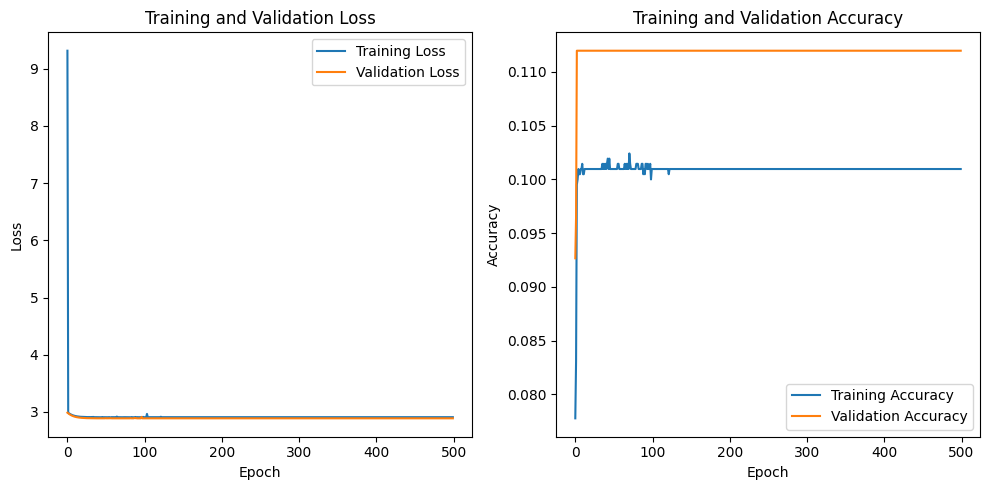

In [21]:
# Get training and validation loss
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Get training and validation accuracy
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [22]:
def plot_image(i, predictions_array, true_label, img, class_names):
    true_label, img = true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img, cmap=plt.cm.binary)

    predicted_label = np.argmax(predictions_array)
    if predicted_label == true_label:
        color = 'blue'
    else:
        color = 'red'

    plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                         100*np.max(predictions_array),
                                         class_names[true_label]),
               color=color)

def plot_value_array(i, predictions_array, true_label, class_names):
    true_label = true_label[i]
    plt.grid(False)
    plt.xticks(range(len(class_names)))
    plt.yticks([])
    thisplot = plt.bar(range(len(class_names)), predictions_array, color="#777777")
    plt.ylim([0, 1])
    predicted_label = np.argmax(predictions_array)

    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('blue')

In [23]:
predictions = model.predict(X_test)

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


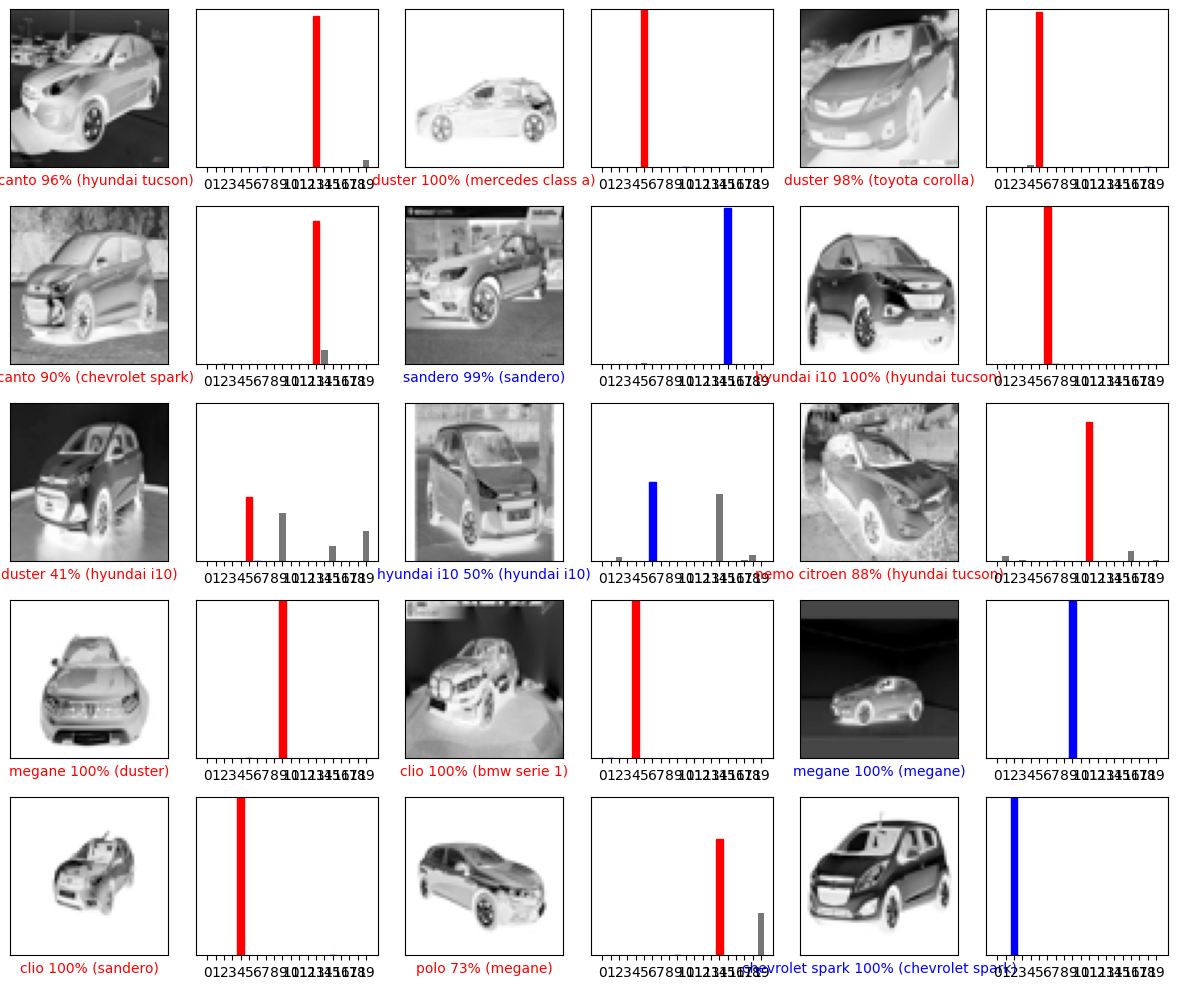

In [24]:
num_rows = 5
num_cols = 3
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_image(i, predictions[i],y_test, X_test, categories)
    plt.subplot(num_rows, 2*num_cols, 2*i+2)
    plot_value_array(i, predictions[i],  y_test, categories)
plt.tight_layout()
plt.show()

In [25]:
predictions = model2.predict(X_test)

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step


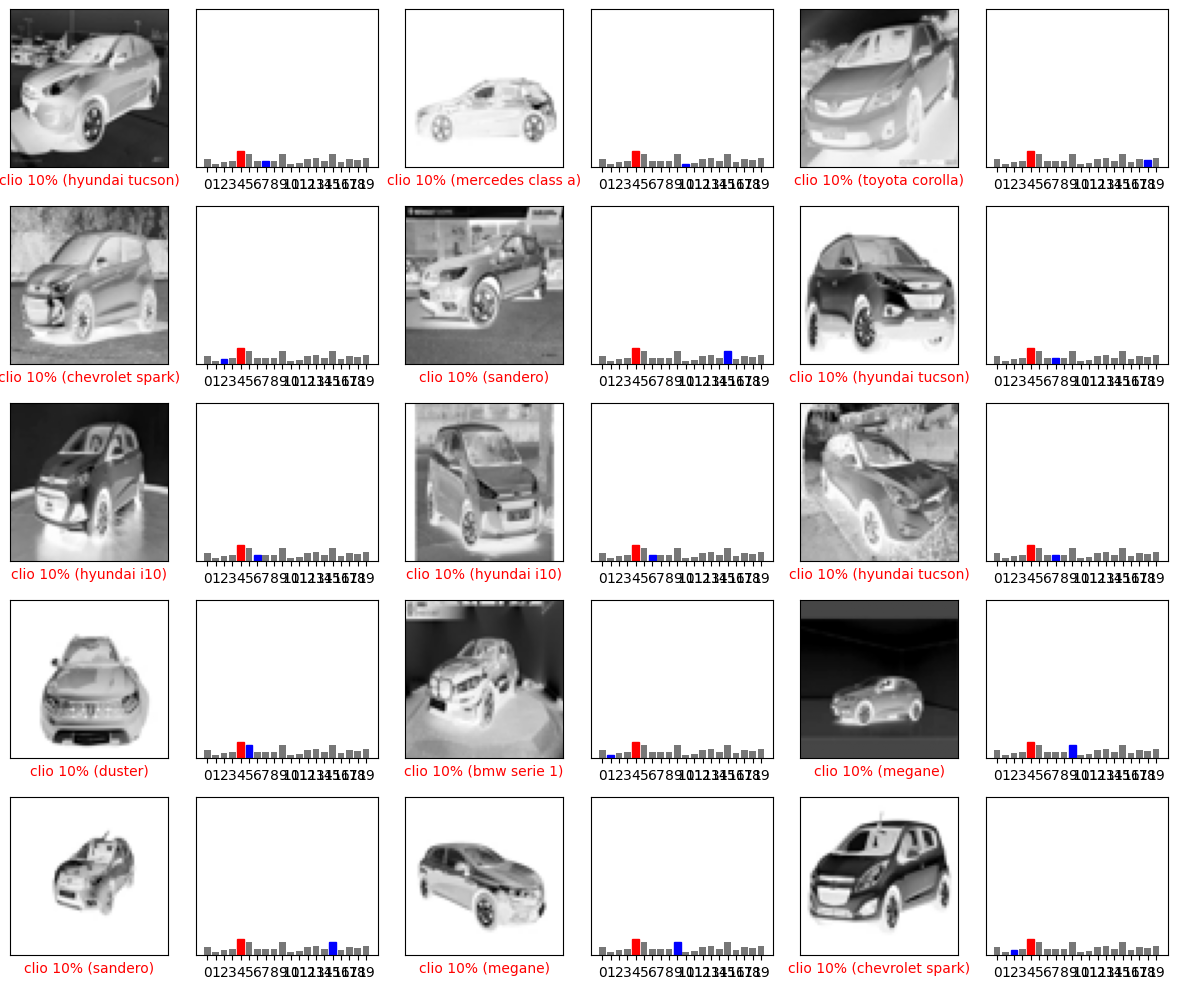

In [26]:
num_rows = 5
num_cols = 3
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_image(i, predictions[i],y_test, X_test, categories)
    plt.subplot(num_rows, 2*num_cols, 2*i+2)
    plot_value_array(i, predictions[i],  y_test, categories)
plt.tight_layout()
plt.show()

In [27]:
# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10)

In [28]:
# Define the model
model1 = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(len(categories), activation='softmax')
])

In [29]:
# Compile the model
model1.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

In [30]:
# Train the model with early stopping
history = model1.fit(X_train, y_train, epochs=500, batch_size=32, validation_split=0.2, callbacks=[early_stopping])

Epoch 1/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.0841 - loss: 6.8579 - val_accuracy: 0.1351 - val_loss: 2.8673
Epoch 2/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.1778 - loss: 2.7428 - val_accuracy: 0.2124 - val_loss: 2.6711
Epoch 3/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2870 - loss: 2.3452 - val_accuracy: 0.2375 - val_loss: 2.5093
Epoch 4/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4227 - loss: 1.8783 - val_accuracy: 0.3205 - val_loss: 2.4550
Epoch 5/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5816 - loss: 1.3898 - val_accuracy: 0.3456 - val_loss: 2.3452
Epoch 6/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7164 - loss: 0.9574 - val_accuracy: 0.3996 - val_loss: 2.4480
Epoch 7/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8372 - loss: 0.5575 - val_accuracy: 0.4305 - val_loss: 2.4377
Epoch 8/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9150 - loss: 0.3097 - val_accuracy: 0.4556 - 

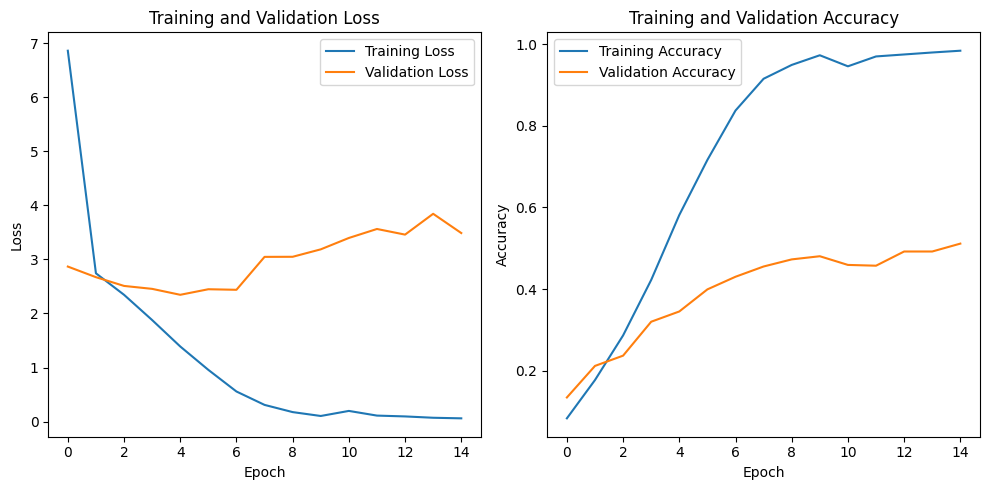

In [31]:
# Get training and validation loss
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Get training and validation accuracy
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [32]:
# Evaluate the model on the test set
test_loss, test_accuracy = model1.evaluate(X_test, y_test)
print("Loss:", test_loss)
print("Accuracy:", test_accuracy)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4451 - loss: 3.9680
Loss: 3.9679818153381348
Accuracy: 0.4451313614845276


###Padding

In [33]:
# Define the model with padding='same'
model3 = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(img_size, img_size, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(categories), activation='softmax')
])

In [34]:
# Compile the model
model3.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [35]:
# Train the model with early stopping
history = model3.fit(X_train, y_train, epochs=500, batch_size=32, validation_split=0.2)

Epoch 1/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 66ms/step - accuracy: 0.0850 - loss: 4.6674 - val_accuracy: 0.1120 - val_loss: 2.9860
Epoch 2/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.1010 - loss: 2.9826 - val_accuracy: 0.1120 - val_loss: 2.9752
Epoch 3/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.1010 - loss: 2.9736 - val_accuracy: 0.1120 - val_loss: 2.9656
Epoch 4/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.1010 - loss: 2.9652 - val_accuracy: 0.1120 - val_loss: 2.9563
Epoch 5/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.1010 - loss: 2.9579 - val_accuracy: 0.1120 - val_loss: 2.9483
Epoch 6/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1010 - loss: 2.9513 - val_accuracy: 0.1120 - val_loss: 2.9410
Epoch 7/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.1010 - loss: 2.9455 - val_accuracy: 0.1120 - val_loss: 2.9344
Epoch 8/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1010 - loss: 2.9405 - val_accuracy: 0.1120 

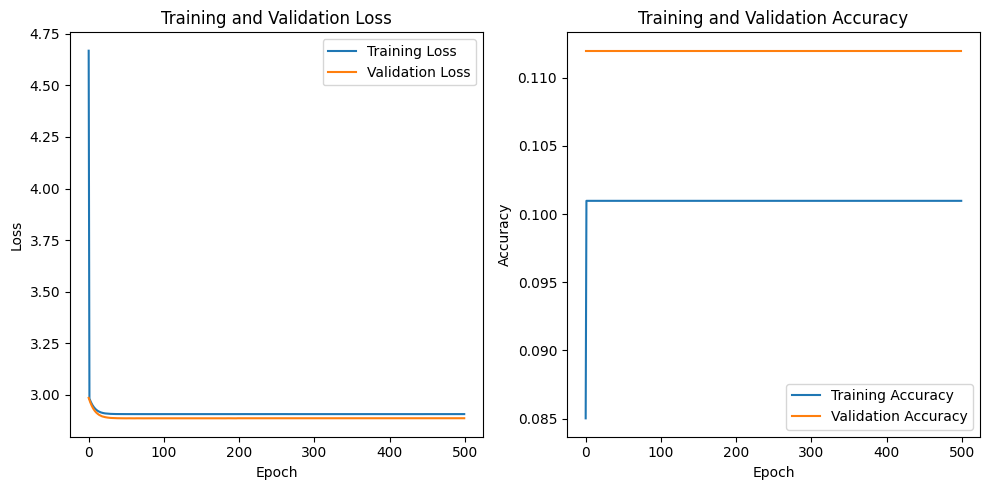

In [36]:
# Get training and validation loss
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Get training and validation accuracy
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [37]:
# Evaluate the model on the test set
test_loss, test_accuracy = model3.evaluate(X_test, y_test)
print("Loss:", test_loss)
print("Accuracy:", test_accuracy)

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.1190 - loss: 2.9203
Loss: 2.920313835144043
Accuracy: 0.1190108209848404


In [38]:
# Define the model with drop out
model4 = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(img_size, img_size, 1)),
    MaxPooling2D((2, 2)),
    Dropout(0.25),  # Adding dropout after the first pooling layer
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),  # Adding dropout after the second pooling layer
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),  # Adding dropout after the third pooling layer
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),   # Adding dropout before the output layer
    Dense(len(categories), activation='softmax')
])

In [39]:
# Compile the model
model4.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [40]:
# Train the model with early stopping
history = model4.fit(X_train, y_train, epochs=500, batch_size=32, validation_split=0.2)

Epoch 1/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 15s 95ms/step - accuracy: 0.0710 - loss: 8.8691 - val_accuracy: 0.0985 - val_loss: 2.9821
Epoch 2/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.0874 - loss: 2.9763 - val_accuracy: 0.1062 - val_loss: 2.9490
Epoch 3/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.0870 - loss: 2.9606 - val_accuracy: 0.1004 - val_loss: 2.9450
Epoch 4/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0981 - loss: 2.9483 - val_accuracy: 0.1081 - val_loss: 2.9212
Epoch 5/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.0981 - loss: 2.9287 - val_accuracy: 0.1139 - val_loss: 2.9108
Epoch 6/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.0976 - loss: 2.9303 - val_accuracy: 0.1120 - val_loss: 2.8979
Epoch 7/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.0990 - loss: 2.9213 - val_accuracy: 0.1139 - val_loss: 2.8836
Epoch 8/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.1063 - loss: 2.9178 - val_accuracy: 0.1236

In [41]:
# Evaluate the model on the test set
test_loss, test_accuracy = model4.evaluate(X_test, y_test)
print("Loss:", test_loss)
print("Accuracy:", test_accuracy)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6352 - loss: 2.3769
Loss: 2.3768911361694336
Accuracy: 0.6352395415306091


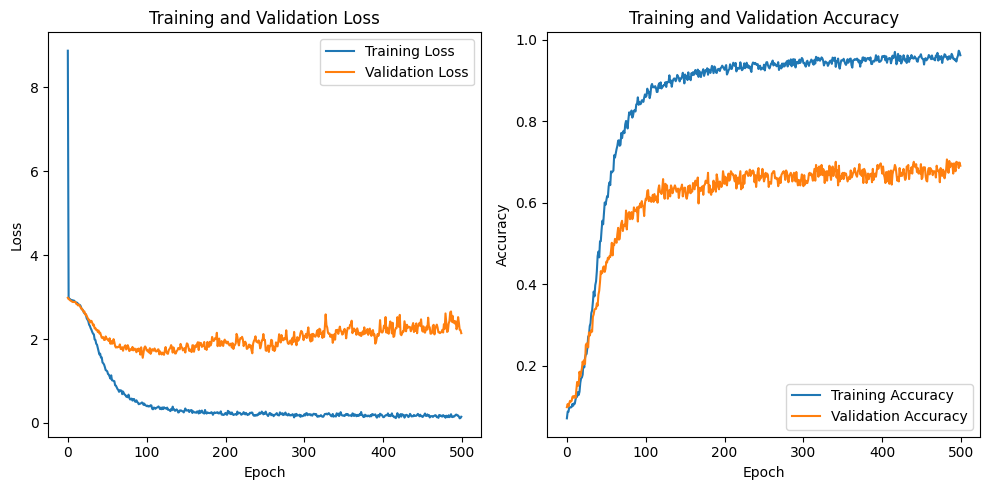

In [42]:
# Get training and validation loss
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Get training and validation accuracy
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()